In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
transactions = pd.read_csv('FinTrust_Transaction_Data_Cleaned_Latest.csv')
customers = pd.read_csv('FinTrust_Customer_Data_Cleaned_Latest.csv')


In [4]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               1500 non-null   object 
 1   Customer_Name             1500 non-null   object 
 2   Age                       1500 non-null   int64  
 3   Gender                    1500 non-null   object 
 4   City                      1500 non-null   object 
 5   Customer_Segment          1500 non-null   object 
 6   Account_Type              1500 non-null   object 
 7   Tenure_Months             1500 non-null   int64  
 8   Digital_Engagement_Score  1500 non-null   float64
 9   Monthly_Income_Band       1500 non-null   object 
 10  Preferred_Channel         1500 non-null   object 
 11  Account_Status            1500 non-null   object 
dtypes: float64(1), int64(2), object(9)
memory usage: 140.8+ KB


In [6]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Transaction_ID             12000 non-null  object 
 1   Customer_ID                12000 non-null  object 
 2   Transaction_DateTime       12000 non-null  object 
 3   Transaction_Type           12000 non-null  object 
 4   Amount_NGN                 12000 non-null  float64
 5   Channel                    12000 non-null  object 
 6   Device_Type                12000 non-null  object 
 7   Location                   12000 non-null  object 
 8   International_Transaction  12000 non-null  object 
 9   Transaction_Status         12000 non-null  object 
 10  Risk_Review_Flag           12000 non-null  object 
dtypes: float64(1), object(10)
memory usage: 1.0+ MB


In [7]:
transactions["Transaction_DateTime"] = pd.to_datetime(transactions["Transaction_DateTime"])
print(transactions["Transaction_DateTime"].dtypes)

C:\Users\akand\AppData\Local\Temp\ipykernel_36936\1028790033.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  transactions["Transaction_DateTime"] = pd.to_datetime(transactions["Transaction_DateTime"])


datetime64[ns]


In [8]:
transactions["Transaction_Status"].value_counts()

Transaction_Status
Successful    10856
Failed          630
Reversed        326
Pending         188
Name: count, dtype: int64

In [9]:
transactions["Transaction_Status"].value_counts(normalize=True) * 100

Transaction_Status
Successful    90.466667
Failed         5.250000
Reversed       2.716667
Pending        1.566667
Name: proportion, dtype: float64

In [10]:
print(f"{(transactions['Transaction_Status'] == 'Failed').mean() * 100:.2f}%")

5.25%


Successful transactions account for the majority of transactions at 90.47%. Failed transactions represent 5.25%, while reversed and pending transactions account for 2.72% and 1.57%, respectively.

In [11]:
customers['Gender'].value_counts()

Gender
Male                 727
Female               722
Prefer not to say     51
Name: count, dtype: int64

In [12]:
customers["Gender"].value_counts(normalize=True) * 100

Gender
Male                 48.466667
Female               48.133333
Prefer not to say     3.400000
Name: proportion, dtype: float64

The customer base is almost evenly split between male (48.47%) and female (48.13%) customers. 3.40% prefer not to say.

In [13]:
customers['City'].value_counts()

City
Lagos            488
Abuja            223
Port Harcourt    172
Kano             159
Ibadan           148
Enugu            108
Kaduna           103
Benin City        99
Name: count, dtype: int64

In [14]:
customers["City"].value_counts(normalize=True) * 100

City
Lagos            32.533333
Abuja            14.866667
Port Harcourt    11.466667
Kano             10.600000
Ibadan            9.866667
Enugu             7.200000
Kaduna            6.866667
Benin City        6.600000
Name: proportion, dtype: float64

Lagos has the largest share of customers (32.53%), followed by Abuja (14.87%). The remaining cities each account for less than 12% of the customer base.

In [15]:
customers['Account_Type'].value_counts()

Account_Type
Savings    893
Current    378
Premium    229
Name: count, dtype: int64

In [16]:
customers["Account_Type"].value_counts(normalize=True) * 100

Account_Type
Savings    59.533333
Current    25.200000
Premium    15.266667
Name: proportion, dtype: float64

### Account type

Savings accounts represent the largest share of customers (59.53%), followed by Current (25.20%) and Premium accounts (15.27%).

In [17]:
customers["Age_Group"] = pd.cut(
    customers["Age"],
    bins=[17, 24, 34, 44, 54, 64, 100],
    labels=["18–24", "25–34", "35–44", "45–54", "55–64", "65+"]
)

In [18]:
customers["Age_Group"].value_counts().sort_index()

Age_Group
18–24    217
25–34    297
35–44    322
45–54    343
55–64    295
65+       26
Name: count, dtype: int64

In [19]:
customers["Age_Group"].value_counts(normalize=True).sort_index() * 100

Age_Group
18–24    14.466667
25–34    19.800000
35–44    21.466667
45–54    22.866667
55–64    19.666667
65+       1.733333
Name: proportion, dtype: float64


### Age Group

The largest age group is 45–54 (22.87%), followed by 35–44 (21.47%). Customers aged 25–34 and 55–64 each represent about 20% of the customer base, while 65+ is the smallest group at 1.73%.

In [20]:
customers['Customer_Segment'].value_counts()

Customer_Segment
Everyday    711
Premium     295
Student     278
SME         216
Name: count, dtype: int64

In [21]:
customers["Customer_Segment"].value_counts(normalize=True) * 100

Customer_Segment
Everyday    47.400000
Premium     19.666667
Student     18.533333
SME         14.400000
Name: proportion, dtype: float64

### Customer Segment

Everyday customers make up the largest segment at 47.40%, followed by Premium customers at 19.67%, Student customers at 18.53%, and SME customers at 14.40%.

In [22]:
customers['Monthly_Income_Band'].value_counts()

Monthly_Income_Band
100k-249k     430
250k-499k     416
Below 100k    265
500k-999k     255
1m+           134
Name: count, dtype: int64

In [23]:
customers["Monthly_Income_Band"].value_counts(normalize=True) * 100

Monthly_Income_Band
100k-249k     28.666667
250k-499k     27.733333
Below 100k    17.666667
500k-999k     17.000000
1m+            8.933333
Name: proportion, dtype: float64


### Monthly Income Band

Customers earning 100k–249k represent the largest share at 28.67%, closely followed by 250k–499k at 27.73%. Customers in the 1m+ income band represent the smallest share at 8.93%.

In [24]:
customers['Preferred_Channel'].value_counts()


Preferred_Channel
Mobile App    924
Web           357
USSD          219
Name: count, dtype: int64

In [25]:
customers["Preferred_Channel"].value_counts(normalize=True) * 100

Preferred_Channel
Mobile App    61.6
Web           23.8
USSD          14.6
Name: proportion, dtype: float64

### Preferred Channel

The Mobile App is the most preferred channel, used by 61.60% of customers, followed by Web (23.80%) and USSD (14.60%).

In [26]:
customers['Account_Status'].value_counts()


Account_Status
Active        1367
Dormant        107
Restricted      26
Name: count, dtype: int64

In [27]:
customers["Account_Status"].value_counts(normalize=True) * 100

Account_Status
Active        91.133333
Dormant        7.133333
Restricted     1.733333
Name: proportion, dtype: float64

### Account Status 

The majority of customers have Active accounts (91.13%), while 7.13% are Dormant and 1.73% are Restricted.

In [28]:
customers[['Age', 'Tenure_Months', "Digital_Engagement_Score"]].describe()

,Age,Tenure_Months,Digital_Engagement_Score
count,1500.000000,1500.000000,1500.000000
mean,41.587333,49.858667,67.954000
std,13.733127,27.910990,17.555376
min,18.000000,1.000000,16.700000
25%,29.750000,26.000000,56.100000
50%,42.000000,51.000000,68.000000
75%,53.000000,74.000000,80.925000
max,65.000000,96.000000,100.000000


In [29]:
customers.corr(numeric_only=True).round(2)

,Age,Tenure_Months,Digital_Engagement_Score
Age,1.00,-0.02,-0.00
Tenure_Months,-0.02,1.00,0.02
Digital_Engagement_Score,-0.00,0.02,1.00


### Correlation matrix

Age, tenure, and digital engagement show negligible linear correlations with each other, with correlation coefficients ranging from approximately -0.02 to 0.02.

In [30]:
customers["Tenure_Group"] = pd.cut(
    customers["Tenure_Months"],
    bins=[0, 12, 24, 36, 60, 96],
    labels=["0–12 months", "13–24 months", "25–36 months",
            "37–60 months", "61–96 months"]
)

In [31]:
customers["Tenure_Group"].value_counts().sort_index()


Tenure_Group
0–12 months     173
13–24 months    179
25–36 months    190
37–60 months    360
61–96 months    598
Name: count, dtype: int64

In [32]:
customers["Tenure_Group"].value_counts(normalize=True).sort_index() * 100

Tenure_Group
0–12 months     11.533333
13–24 months    11.933333
25–36 months    12.666667
37–60 months    24.000000
61–96 months    39.866667
Name: proportion, dtype: float64

### Tenure Distribution

Customers with 61–96 months of tenure make up the largest share of the customer base at 39.87%, followed by 37–60 months at 24.00%. The three shorter-tenure groups each account for approximately 12% of customers

In [33]:
customers["Engagement_Group"] = pd.cut(
    customers["Digital_Engagement_Score"],
    bins=[0, 39, 59, 79, 100],
    labels=["Low", "Moderate", "High", "Very High"]
)

In [34]:
customers["Engagement_Group"].value_counts().sort_index()

Engagement_Group
Low           87
Moderate     391
High         584
Very High    438
Name: count, dtype: int64

In [35]:
customers["Engagement_Group"].value_counts(normalize=True).sort_index() * 100

Engagement_Group
Low           5.800000
Moderate     26.066667
High         38.933333
Very High    29.200000
Name: proportion, dtype: float64

### Digital Engagement Distribution

The largest share of customers falls into the High engagement group at 38.93%, followed by Very High (29.20%) and Moderate (26.07%). The Low engagement group represents only 5.80% of customers.

### Transactions

In [36]:
transactions.describe()

,Transaction_DateTime,Amount_NGN
count,12000,12000.000000
mean,2026-04-08 18:35:51.109999872,46706.446238
min,2026-01-01 00:00:00,100.170000
25%,2026-02-01 11:57:15,2192.220000
50%,2026-03-14 00:02:30,10305.935000
75%,2026-05-02 11:41:30,48484.475000
max,2026-12-03 23:50:00,693454.450000
std,NaN,86028.715234


The transaction dataset contains 12,000 transactions. Transaction amounts range from ₦100.17 to ₦693,454.45, with a median of ₦10,305.94 and a mean of ₦46,706.45. The large difference between the mean and median indicates that transaction amounts are strongly right-skewed, with some higher-value transactions pulling the mean upward. Transaction dates range from 1 January 2026 to 3 December 2026.

In [37]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Transaction_ID             12000 non-null  object        
 1   Customer_ID                12000 non-null  object        
 2   Transaction_DateTime       12000 non-null  datetime64[ns]
 3   Transaction_Type           12000 non-null  object        
 4   Amount_NGN                 12000 non-null  float64       
 5   Channel                    12000 non-null  object        
 6   Device_Type                12000 non-null  object        
 7   Location                   12000 non-null  object        
 8   International_Transaction  12000 non-null  object        
 9   Transaction_Status         12000 non-null  object        
 10  Risk_Review_Flag           12000 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(9)
memory usage: 1.0+ MB


In [38]:
transactions["Location"].value_counts()

Location
Ibadan           1550
Kano             1526
Port Harcourt    1520
Enugu            1484
Kaduna           1481
Abuja            1461
Benin City       1451
Lagos            1431
Unknown            96
Name: count, dtype: int64

In [39]:
transactions["Location"].value_counts(normalize=True) * 100

Location
Ibadan           12.916667
Kano             12.716667
Port Harcourt    12.666667
Enugu            12.366667
Kaduna           12.341667
Abuja            12.175000
Benin City       12.091667
Lagos            11.925000
Unknown           0.800000
Name: proportion, dtype: float64

### Transaction location
Transaction activity is relatively evenly distributed across the eight recorded locations, with shares ranging from 11.93% in Lagos to 12.92% in Ibadan. Unknown accounts for 0.80% of transactions due to previously missing location values.

In [40]:
transactions["Transaction_Type"].value_counts()

Transaction_Type
Transfer           3549
Card Purchase      3033
Bill Payment       1475
Cash Withdrawal    1430
Deposit            1328
Airtime/Data       1185
Name: count, dtype: int64

In [41]:
transactions["Transaction_Type"].value_counts(normalize=True) * 100

Transaction_Type
Transfer           29.575000
Card Purchase      25.275000
Bill Payment       12.291667
Cash Withdrawal    11.916667
Deposit            11.066667
Airtime/Data        9.875000
Name: proportion, dtype: float64

### Transaction Type
Transfers account for the largest share of transactions at 29.58%, followed by Card Purchases at 25.28%. Bill Payments, Cash Withdrawals, Deposits, and Airtime/Data transactions each account for between approximately 9.88% and 12.29% of total transactions.

In [42]:
transactions["Channel"].value_counts()

Channel
Mobile App    5102
POS           2393
Web           1869
ATM           1747
USSD           889
Name: count, dtype: int64

In [43]:
transactions["Channel"].value_counts(normalize=True) * 100

Channel
Mobile App    42.516667
POS           19.941667
Web           15.575000
ATM           14.558333
USSD           7.408333
Name: proportion, dtype: float64

### Transaction Channel
Mobile App is the most frequently used transaction channel, accounting for 42.52% of all transactions. POS accounts for 19.94%, followed by Web (15.58%), ATM (14.56%), and USSD (7.41%)

In [44]:
transactions["Device_Type"].value_counts()

Device_Type
Android         4797
iOS             2920
POS Terminal    1571
Web Browser     1447
ATM Terminal    1169
Unknown           96
Name: count, dtype: int64

In [45]:
transactions["Device_Type"].value_counts(normalize=True) * 100

Device_Type
Android         39.975000
iOS             24.333333
POS Terminal    13.091667
Web Browser     12.058333
ATM Terminal     9.741667
Unknown          0.800000
Name: proportion, dtype: float64

### Device Type

Android devices account for the largest share of transactions at 39.98%, followed by iOS at 24.33%. POS Terminal, Web Browser, and ATM Terminal account for 13.09%, 12.06%, and 9.74%, respectively. Unknown represents 0.80% of transactions.

In [46]:
transactions["International_Transaction"].value_counts()

International_Transaction
No     11520
Yes      480
Name: count, dtype: int64

In [47]:
transactions["International_Transaction"].value_counts(normalize=True) * 100

International_Transaction
No     96.0
Yes     4.0
Name: proportion, dtype: float64

### International Transaction
The majority of transactions are domestic (96.00%), while international transactions account for 4.00% of all transactions.

In [48]:
transactions["Risk_Review_Flag"].value_counts()

Risk_Review_Flag
No     9648
Yes    2352
Name: count, dtype: int64

In [49]:
transactions["Risk_Review_Flag"].value_counts(normalize=True) * 100

Risk_Review_Flag
No     80.4
Yes    19.6
Name: proportion, dtype: float64

### Risk Review Flag
80.40% of transactions were not flagged for risk review, while 19.60% were flagged for review.

In [50]:
df = transactions.merge(
    customers,
    on="Customer_ID",
    how="left"
)

In [51]:
pd.crosstab(
    df["Age_Group"],
    df["Transaction_Status"],
    normalize="index"
) * 100

Transaction_Status,Failed,Pending,Reversed,Successful
Age_Group,,,,
18–24,5.292793,1.520270,2.759009,90.427928
25–34,5.331654,1.721243,2.560873,90.386230
35–44,5.448085,1.500197,2.289775,90.761942
45–54,5.499814,1.263471,2.712746,90.523969
55–64,4.976997,1.923881,3.011292,90.087829
65+,1.762115,0.881057,5.726872,91.629956


### Age Group

Failed transaction rates are relatively similar across customers aged 18–64, ranging from 4.98% to 5.50%. The 45–54 group has the highest failed rate at 5.50%, while the 65+ group has a considerably lower rate of 1.76%. The 65+ result should be interpreted cautiously due to its smaller customer base.

In [52]:
pd.crosstab(
    df["Gender"],
    df["Transaction_Status"],
    normalize="index"
) * 100

Transaction_Status,Failed,Pending,Reversed,Successful
Gender,,,,
Female,5.205291,1.546126,2.594056,90.654527
Male,5.190550,1.551992,2.828074,90.429384
Prefer not to say,6.842105,2.105263,2.894737,88.157895


### Transaction Performance  by Gender

Failed transaction rates are almost identical for female (5.21%) and male (5.19%) customers, with only a 0.02 percentage-point difference. The “Prefer not to say” group has a higher rate of 6.84%, but this group has a smaller customer base and should be interpreted cautiously.

In [53]:
df.groupby("Transaction_Type")["Transaction_Status"].agg(
    total="count",
    failed=lambda x: (x == "Failed").sum(),
    failure_rate=lambda x: (x == "Failed").mean() * 100
).sort_values("failure_rate", ascending=False)

,total,failed,failure_rate
Transaction_Type,,,
Bill Payment,1475,86,5.830508
Airtime/Data,1185,63,5.316456
Transfer,3549,187,5.269090
Card Purchase,3033,159,5.242334
Cash Withdrawal,1430,73,5.104895
Deposit,1328,62,4.668675


### Transaction Performance by Trsasaction Types

Failed transaction rates are relatively similar across transaction types, ranging from 4.67% to 5.83%. Bill Payments have the highest failed rate, while Deposits have the lowest, but the difference between them is relatively small.

In [54]:
df.groupby("Channel")["Transaction_Status"].agg(
    total="count",
    failed=lambda x: (x == "Failed").sum(),
    failure_rate=lambda x: (x == "Failed").mean() * 100
).sort_values("failure_rate", ascending=False)

,total,failed,failure_rate
Channel,,,
Mobile App,5102,296,5.801646
USSD,889,48,5.399325
POS,2393,125,5.223569
Web,1869,88,4.708400
ATM,1747,73,4.178592


### Transaction Performance by Channels

Failed transaction rates are relatively similar across channels, ranging from 4.18% to 5.80%. Mobile App has the highest failed rate, while ATM has the lowest, but the overall difference is relatively small.

In [55]:
df.groupby("Location")["Transaction_Status"].agg(
    total="count",
    failed=lambda x: (x == "Failed").sum(),
    failure_rate=lambda x: (x == "Failed").mean() * 100
).sort_values("failure_rate", ascending=False)

,total,failed,failure_rate
Location,,,
Kano,1526,92,6.028834
Port Harcourt,1520,85,5.592105
Benin City,1451,79,5.444521
Ibadan,1550,84,5.419355
Lagos,1431,76,5.310971
Enugu,1484,72,4.851752
Kaduna,1481,70,4.726536
Abuja,1461,68,4.654346
Unknown,96,4,4.166667


### Transaction Performance by Location

Failed transaction rates are relatively similar across locations, ranging from 4.65% to 6.03% among recorded locations. Kano has the highest failed rate, while Abuja has the lowest. The difference is relatively small, suggesting no major variation in failed rates across locations. The Unknown category represents only 96 transactions and should be interpreted cautiously.

In [56]:
df.groupby("Device_Type")["Transaction_Status"].agg(
    total="count",
    failed=lambda x: (x == "Failed").sum(),
    failure_rate=lambda x: (x == "Failed").mean() * 100
).sort_values("failure_rate", ascending=False)

,total,failed,failure_rate
Device_Type,,,
Unknown,96,6,6.250000
iOS,2920,168,5.753425
Android,4797,258,5.378361
POS Terminal,1571,77,4.901337
ATM Terminal,1169,57,4.875962
Web Browser,1447,64,4.422944


### Transaction Performance by Device Type

Device type showed relatively small differences in failed transaction rates. iOS had the highest failure rate among known device types at 5.75% (168 of 2,920 transactions), compared with the overall failure rate of 5.25%. Web Browser had the lowest rate at 4.42% (64 of 1,447 transactions). The Unknown category had a 6.25% failure rate, but it was based on only 96 transactions.

Overall, the differences were not large enough to identify Device Type as a strong association with failed transactions at the overall dataset level.

In [57]:
df["Hour"] = df["Transaction_DateTime"].dt.hour

In [58]:
df["Time_of_Day"] = pd.cut(
    df["Hour"],
    bins=[-1, 5, 11, 17, 23],
    labels=["Night", "Morning", "Afternoon", "Evening"]
)

In [59]:
df.groupby("Time_of_Day")["Transaction_Status"].agg(
    total="count",
    failed=lambda x: (x == "Failed").sum(),
    failure_rate=lambda x: (x == "Failed").mean() * 100
).sort_values("failure_rate", ascending=False)

C:\Users\akand\AppData\Local\Temp\ipykernel_36936\1396601197.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Time_of_Day")["Transaction_Status"].agg(


,total,failed,failure_rate
Time_of_Day,,,
Afternoon,3000,178,5.933333
Evening,3000,177,5.900000
Morning,3000,145,4.833333
Night,3000,130,4.333333


### Transaction Performance by Time of Day

Failed transaction rates are relatively similar across time periods, although Afternoon has the highest rate (5.93%), closely followed by Evening (5.90%). Night has the lowest rate at 4.33%.

In [60]:
df.groupby("Risk_Review_Flag")["Transaction_Status"].agg(
    total="count",
    failed=lambda x: (x == "Failed").sum(),
    failure_rate=lambda x: (x == "Failed").mean() * 100
).sort_values("failure_rate", ascending=False)

,total,failed,failure_rate
Risk_Review_Flag,,,
Yes,2352,170,7.227891
No,9648,460,4.767828


### Transaction Performance by Risk Review

flagged for risk review have a higher failed transaction rate (7.23%) compared with transactions not flagged (4.77%). This indicates an association between risk review status and failed transactions, although it does not establish that the risk flag itself causes the failure.

In [61]:
df.groupby("Customer_Segment")["Transaction_Status"].agg(
    total="count",
    failed=lambda x: (x == "Failed").sum(),
    failure_rate=lambda x: (x == "Failed").mean() * 100
).sort_values("failure_rate", ascending=False)

,total,failed,failure_rate
Customer_Segment,,,
Student,2289,131,5.723023
SME,1706,92,5.392732
Everyday,5644,298,5.279943
Premium,2361,109,4.616688


### Transaction Performance by Customer Segments

Failed transaction rates are relatively similar across customer segments, ranging from 4.62% to 5.72%. Student customers have the highest failed rate, while Premium customers have the lowest, but the overall difference is relatively small.

In [62]:
df.groupby("Account_Type")["Transaction_Status"].agg(
    total="count",
    failed=lambda x: (x == "Failed").sum(),
    failure_rate=lambda x: (x == "Failed").mean() * 100
).sort_values("failure_rate", ascending=False)

,total,failed,failure_rate
Account_Type,,,
Savings,7149,393,5.497272
Premium,1828,91,4.978118
Current,3023,146,4.829639


### Transaction Performance by Account Types

Failed transaction rates are relatively similar across account types, ranging from 4.83% to 5.50%. Savings accounts have the highest failed rate, while Current accounts have the lowest, with only a small difference between them.

In [63]:
df.groupby("Engagement_Group")["Transaction_Status"].agg(
    total="count",
    failed=lambda x: (x == "Failed").sum(),
    failure_rate=lambda x: (x == "Failed").mean() * 100
).sort_values("failure_rate", ascending=False)

C:\Users\akand\AppData\Local\Temp\ipykernel_36936\1504608199.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Engagement_Group")["Transaction_Status"].agg(


,total,failed,failure_rate
Engagement_Group,,,
High,4679,268,5.727720
Very High,3534,176,4.980192
Moderate,3095,154,4.975767
Low,692,32,4.624277


### Transaction Performance by Engagement Groups

Failed transaction rates are relatively similar across engagement groups, ranging from 4.62% to 5.73%. The High engagement group has the highest failed rate, while the Low engagement group has the lowest, but there is no clear consistent relationship between engagement level and failed transaction rate.

In [64]:
df.groupby("International_Transaction")["Transaction_Status"].agg(
    total="count",
    failed=lambda x: (x == "Failed").sum(),
    failure_rate=lambda x: (x == "Failed").mean() * 100
).sort_values("failure_rate", ascending=False)

,total,failed,failure_rate
International_Transaction,,,
No,11520,618,5.364583
Yes,480,12,2.500000


### Transaction Performance by International Transaction

International transactions have a lower failed transaction rate (2.50%) than domestic transactions (5.36%), a difference of 2.86 percentage points. However, international transactions represent only 4% of the dataset, with just 12 failed transactions, so this relationship should be interpreted cautiously.

In [65]:
df.groupby("Transaction_Status")["Amount_NGN"].describe()

,count,mean,std,min,25%,50%,75%,max
Transaction_Status,,,,,,,,
Failed,630.0,39405.954127,73611.678019,100.17,2134.3550,10558.075,40127.1675,652685.59
Pending,188.0,49032.149096,84843.970548,159.55,2897.6875,11495.465,61819.2550,640656.10
Reversed,326.0,47932.878098,81568.176485,103.14,2965.7875,13341.130,55458.7175,686958.44
Successful,10856.0,47053.006767,86835.282442,100.20,2161.1825,10108.320,48673.0650,693454.45


### Transaction Amount

Transaction amounts show relatively similar median values across failed and successful transactions, with failed transactions having a slightly higher median (₦10,558) than successful transactions (₦10,108). Successful transactions have a higher mean (₦47,053) than failed transactions (₦39,406), suggesting that higher-value transactions contribute to the difference in means. Overall, there is no clear strong relationship between transaction amount and transaction outcome from the summary statistics alone

In [66]:
df.groupby("Tenure_Group")["Transaction_Status"].agg(
    total="count",
    failed=lambda x: (x == "Failed").sum(),
    failure_rate=lambda x: (x == "Failed").mean() * 100
).sort_values("failure_rate", ascending=False)

C:\Users\akand\AppData\Local\Temp\ipykernel_36936\160541977.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Tenure_Group")["Transaction_Status"].agg(


,total,failed,failure_rate
Tenure_Group,,,
0–12 months,1447,84,5.805114
37–60 months,2830,151,5.335689
61–96 months,4817,253,5.252232
13–24 months,1407,70,4.975124
25–36 months,1499,72,4.803202


### Transaction Performance by Tenure Group

Transaction failure rates varied across tenure groups, with customers in the 0–12 month group recording the highest failure rate at 5.81%. The 25–36 month group recorded the lowest failure rate at 4.80%. Overall, the differences were relatively small, suggesting that tenure has only a limited association with transaction failure in this dataset.


In [67]:
df.groupby("Monthly_Income_Band")["Transaction_Status"].agg(
    total="count",
    failed=lambda x: (x == "Failed").sum(),
    failure_rate=lambda x: (x == "Failed").mean() * 100
).sort_values("failure_rate", ascending=False)

,total,failed,failure_rate
Monthly_Income_Band,,,
500k-999k,2103,118,5.611032
250k-499k,3357,182,5.421507
100k-249k,3336,179,5.365707
1m+,1075,55,5.116279
Below 100k,2129,96,4.509159


### Transaction Performance by Monthly Income Band

Transaction failure rates varied across income bands. Customers earning 500k–999k recorded the highest failure rate at 5.61%, while customers earning below 100k recorded the lowest at 4.51%. Overall, the differences were relatively small, suggesting that monthly income does not show a strong association with transaction failure in this dataset.

In [68]:
df.groupby("Account_Status")["Transaction_Status"].agg(
    total="count",
    failed=lambda x: (x == "Failed").sum(),
    failure_rate=lambda x: (x == "Failed").mean() * 100
).sort_values("failure_rate", ascending=False)

,total,failed,failure_rate
Account_Status,,,
Dormant,866,48,5.542725
Active,10910,571,5.233731
Restricted,224,11,4.910714


### Transaction Performance by Account Status

Transaction failure rates varied slightly across account statuses. Dormant accounts recorded the highest failure rate at 5.54%, while Restricted accounts recorded the lowest at 4.91%. Active accounts had a failure rate of 5.23%. Overall, the differences were small, suggesting that account status does not show a strong association with transaction failure in this dataset.

In [69]:
df.groupby("City")["Transaction_Status"].agg(
    total="count",
    failed=lambda x: (x == "Failed").sum(),
    failure_rate=lambda x: (x == "Failed").mean() * 100
).sort_values("failure_rate", ascending=False)

,total,failed,failure_rate
City,,,
Benin City,783,45,5.747126
Enugu,878,50,5.694761
Port Harcourt,1425,77,5.403509
Ibadan,1177,62,5.267630
Lagos,3911,204,5.216057
Kaduna,830,42,5.060241
Abuja,1710,86,5.029240
Kano,1286,64,4.976672


 ### Transaction Performance by City

Transaction failure rates varied across cities. Benin City recorded the highest failure rate at 5.75%, followed by Enugu at 5.69%, while Kano recorded the lowest at 4.98%. Overall, the differences were relatively small, suggesting that location may have a limited association with transaction failure in this dataset.

### Investigate transaction patterns among risk-reviewed transactions

In [70]:
risk_reviewed = df[
    df["Risk_Review_Flag"] == "Yes"
]

In [71]:
risk_reviewed.groupby("Transaction_Type")["Transaction_Status"].agg(
    total="count",
    failed=lambda x: (x == "Failed").sum(),
    failure_rate=lambda x: (x == "Failed").mean() * 100
).sort_values("failure_rate", ascending=False)

,total,failed,failure_rate
Transaction_Type,,,
Bill Payment,189,18,9.523810
Card Purchase,395,36,9.113924
Cash Withdrawal,362,28,7.734807
Transfer,1011,68,6.726014
Airtime/Data,180,10,5.555556
Deposit,215,10,4.651163


### Risk-Reviewed Transaction Performance by Transaction Type

Among risk-reviewed transactions, Bill Payment has the highest failed transaction rate (9.52%), while Deposit has the lowest (4.65%), indicating variation in failure rates across transaction types. 


In [72]:
risk_reviewed.groupby("Channel")["Transaction_Status"].agg(
    total="count",
    failed=lambda x: (x == "Failed").sum(),
    failure_rate=lambda x: (x == "Failed").mean() * 100
).sort_values("failure_rate", ascending=False)

,total,failed,failure_rate
Channel,,,
Mobile App,990,82,8.282828
POS,439,30,6.833713
ATM,370,25,6.756757
Web,399,25,6.265664
USSD,154,8,5.194805


### Risk-Reviewed Transaction Performance by Channel

Among risk-reviewed transactions, Mobile App has the highest failed transaction rate at 8.28%, while USSD has the lowest at 5.19%, showing a noticeable difference of 3.09 percentage points across channels.

In [73]:
risk_reviewed.groupby("Device_Type")["Transaction_Status"].agg(
    total="count",
    failed=lambda x: (x == "Failed").sum(),
    failure_rate=lambda x: (x == "Failed").mean() * 100
).sort_values("failure_rate", ascending=False)

,total,failed,failure_rate
Device_Type,,,
Unknown,16,2,12.500000
iOS,540,50,9.259259
ATM Terminal,253,19,7.509881
Android,957,68,7.105538
POS Terminal,295,20,6.779661
Web Browser,291,11,3.780069


### Risk-Reviewed Transaction Performance by Device Type
Among risk-reviewed transactions with known device types, iOS has the highest failed transaction rate at 9.26%, while Web Browser has the lowest at 3.78%, a difference of 5.48 percentage points. The Unknown category has the highest rate at 12.50%, but its small group size limits the strength of this comparison.

In [74]:
risk_reviewed.groupby("Location")["Transaction_Status"].agg(
    total="count",
    failed=lambda x: (x == "Failed").sum(),
    failure_rate=lambda x: (x == "Failed").mean() * 100
).sort_values("failure_rate", ascending=False)

,total,failed,failure_rate
Location,,,
Unknown,13,3,23.076923
Lagos,279,24,8.602151
Kano,300,23,7.666667
Abuja,263,20,7.604563
Ibadan,319,23,7.210031
Kaduna,297,21,7.070707
Benin City,300,20,6.666667
Port Harcourt,301,19,6.312292
Enugu,280,17,6.071429


### Risk-Reviewed Transaction Performance by Location

Among known locations, Lagos has the highest failed transaction rate at 8.60%, while Enugu has the lowest at 6.07%. The difference of 2.53 percentage points is relatively small compared with other variables examined.

In [75]:
risk_reviewed.groupby("Time_of_Day")["Transaction_Status"].agg(
    total="count",
    failed=lambda x: (x == "Failed").sum(),
    failure_rate=lambda x: (x == "Failed").mean() * 100
).sort_values("failure_rate", ascending=False)

C:\Users\akand\AppData\Local\Temp\ipykernel_36936\420325281.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_reviewed.groupby("Time_of_Day")["Transaction_Status"].agg(


,total,failed,failure_rate
Time_of_Day,,,
Evening,501,47,9.381238
Morning,489,39,7.975460
Afternoon,511,39,7.632094
Night,851,45,5.287897


### Risk-Reviewed Transaction Performance by Time of Day

Among risk-reviewed transactions, Evening has the highest failed transaction rate at 9.38%, while Night has the lowest at 5.29%, a difference of 4.09 percentage points. This indicates a noticeable variation in failed transaction rates across time periods.


In [76]:
risk_reviewed.groupby("International_Transaction")["Transaction_Status"].agg(
    total="count",
    failed=lambda x: (x == "Failed").sum(),
    failure_rate=lambda x: (x == "Failed").mean() * 100
).sort_values("failure_rate", ascending=False)

,total,failed,failure_rate
International_Transaction,,,
No,2175,167,7.678161
Yes,177,3,1.694915


### Risk-Reviewed Transaction Performance by International Transaction

Among risk-reviewed transactions, domestic transactions (International = No) have a higher failed transaction rate of 7.68%, compared with 1.69% for international transactions, a difference of 5.98 percentage points. However, only 3 international transactions failed compared with 167 domestic failures, so the international result should be interpreted cautiously due to the smaller number of observations.


In [77]:
risk_reviewed.groupby("Transaction_Status")["Amount_NGN"].describe()

,count,mean,std,min,25%,50%,75%,max
Transaction_Status,,,,,,,,
Failed,170.0,52443.901588,87046.819125,121.25,2208.8375,12973.765,59871.6925,583438.80
Pending,33.0,71513.946061,131472.081324,376.41,6749.7700,13726.140,78288.4100,640656.10
Reversed,60.0,66135.225833,100060.184169,103.14,2435.1775,21082.295,69415.8975,378588.84
Successful,2089.0,70148.441537,113172.895286,107.11,2515.3900,13438.740,84173.8100,693454.45


### Risk-Reviewed Transaction Performance by Transaction Amount

Transaction amounts do not show a strong difference between failed and successful risk-reviewed transactions. The median amount was ₦12,973.77 for failed transactions and ₦13,438.74 for successful transactions, indicating that the typical transaction amounts were relatively similar across the two outcomes. The difference in means is larger, but the high variability in transaction amounts makes the median a more useful measure for this comparison.


## Further investigate risk-reviewed transactions made using iOS devices

In [78]:
ios_risk_reviewed = risk_reviewed[
    risk_reviewed["Device_Type"] == "iOS"
]

In [79]:
ios_risk_reviewed.groupby("Transaction_Type")["Transaction_Status"].agg(
    total="count",
    failed=lambda x: (x == "Failed").sum(),
    failure_rate=lambda x: (x == "Failed").mean() * 100
).sort_values("failure_rate", ascending=False)

,total,failed,failure_rate
Transaction_Type,,,
Bill Payment,49,6,12.244898
Card Purchase,89,10,11.235955
Cash Withdrawal,80,8,10.000000
Transfer,234,21,8.974359
Deposit,48,3,6.250000
Airtime/Data,40,2,5.000000


### Risk-Reviewed iOS Transaction Performance by Transaction Type

Within risk-reviewed iOS transactions, Bill Payment has the highest observed failure rate (12.24%), followed by Card Purchase (11.24%) and Cash Withdrawal (10.00%).

In [80]:
ios_risk_reviewed.groupby("Time_of_Day")["Transaction_Status"].agg(
    total="count",
    failed=lambda x: (x == "Failed").sum(),
    failure_rate=lambda x: (x == "Failed").mean() * 100
).sort_values("failure_rate", ascending=False)

C:\Users\akand\AppData\Local\Temp\ipykernel_36936\3457613631.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ios_risk_reviewed.groupby("Time_of_Day")["Transaction_Status"].agg(


,total,failed,failure_rate
Time_of_Day,,,
Morning,109,15,13.761468
Afternoon,106,11,10.377358
Evening,120,12,10.000000
Night,205,12,5.853659


### Risk-Reviewed iOS Transaction Performance by Time of Day
Within risk-reviewed iOS transactions, Morning has the highest failed transaction rate, while Night has the lowest, showing a noticeable difference across time periods.

In [81]:
ios_risk_reviewed.groupby("Channel")["Transaction_Status"].agg(
    total="count",
    failed=lambda x: (x == "Failed").sum(),
    failure_rate=lambda x: (x == "Failed").mean() * 100
).sort_values("failure_rate", ascending=False)

,total,failed,failure_rate
Channel,,,
USSD,37,4,10.810811
POS,98,10,10.204082
Mobile App,237,22,9.282700
ATM,76,7,9.210526
Web,92,7,7.608696


### Risk-Reviewed iOS Transaction Performance by Channel

Within risk-reviewed iOS transactions, failed rates across channels range from 7.61% for Web to 10.81% for USSD. Although USSD has the highest observed rate, it is based on only 37 transactions, so the difference should be interpreted cautiously. Overall, Channel shows a less pronounced pattern than some of the other variables examined.

In [82]:
ios_risk_reviewed.groupby("International_Transaction")["Transaction_Status"].agg(
    total="count",
    failed=lambda x: (x == "Failed").sum(),
    failure_rate=lambda x: (x == "Failed").mean() * 100
).sort_values("failure_rate", ascending=False)

,total,failed,failure_rate
International_Transaction,,,
No,506,49,9.683794
Yes,34,1,2.941176


### Risk-Reviewed iOS Transaction Performance by International Transaction

Within risk-reviewed iOS transactions, domestic transactions have a higher failed transaction rate of 9.68%, compared with 2.94% for international transactions, a difference of 6.74 percentage points. Although the difference is noticeable, the international group contains only 34 transactions, so the result should be interpreted cautiously.

## Context : Profile Summary

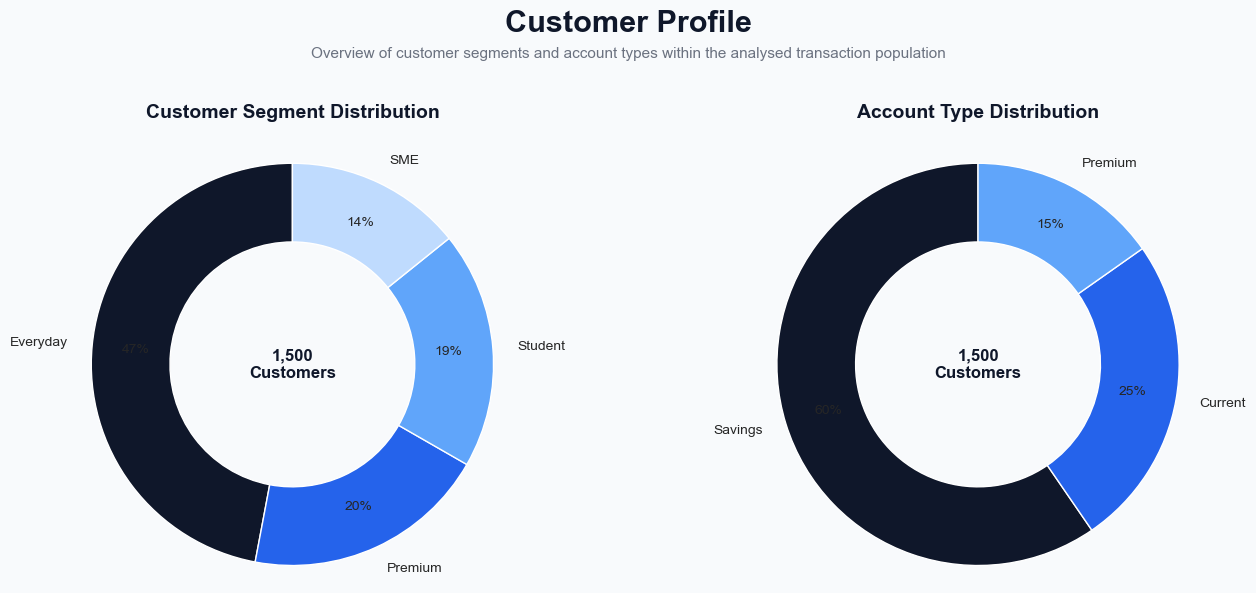

In [83]:


sns.set_style("white")

# Data

customer_segment = (
    df["Customer_Segment"]
    .value_counts()
    .reindex(["Everyday", "Premium", "Student", "SME"])
)

account_type = (
    df["Account_Type"]
    .value_counts()
    .reindex(["Savings", "Current", "Premium"])
)

# Colours

customer_colors = [
    '#0F172A',
    '#2563EB',
    '#60A5FA',
    '#BFDBFE'
]

account_colors = [
    '#0F172A',
    '#2563EB',
    '#60A5FA'
]

# Create figure

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

fig.patch.set_facecolor('#F8FAFC')

# Customer Segment Donut

axes[0].pie(
    customer_segment.values,
    labels=customer_segment.index,
    colors=customer_colors,
    autopct='%1.0f%%',
    startangle=90,
    radius=1.15,
    pctdistance=0.78,
    labeldistance=1.12,
    wedgeprops=dict(
        width=0.45,
        edgecolor='white'
    )
)

axes[0].text(
    0,
    0,
    '1,500\nCustomers',
    ha='center',
    va='center',
    fontsize=12,
    fontweight='bold',
    color='#0F172A'
)

axes[0].set_title(
    'Customer Segment Distribution',
    fontsize=14,
    fontweight='bold',
    color='#0F172A',
    pad=20
)

# Account Type Donut

axes[1].pie(
    account_type.values,
    labels=account_type.index,
    colors=account_colors,
    autopct='%1.0f%%',
    startangle=90,
    radius=1.15,
    pctdistance=0.78,
    labeldistance=1.12,
    wedgeprops=dict(
        width=0.45,
        edgecolor='white'
    )
)

axes[1].text(
    0,
    0,
    '1,500\nCustomers',
    ha='center',
    va='center',
    fontsize=12,
    fontweight='bold',
    color='#0F172A'
)

axes[1].set_title(
    'Account Type Distribution',
    fontsize=14,
    fontweight='bold',
    color='#0F172A',
    pad=20
)

# Main title

plt.suptitle(
    'Customer Profile',
    fontsize=22,
    fontweight='bold',
    color='#0F172A',
    y=0.98
)

# Subtitle

fig.text(
    0.5,
    0.90,
    'Overview of customer segments and account types within the analysed transaction population',
    ha='center',
    fontsize=11,
    color='#6B7280'
)

# Layout

plt.tight_layout(
    rect=[0, 0, 1, 0.92]
)

plt.show()

### What the visual shows

The visual shows the distribution of the 1,500 customers across customer segments and account types. Everyday customers represented the largest customer segment at 47.4%, followed by Premium (19.7%), Student (18.5%), and SME (14.4%). Savings accounts represented the largest account type at 59.5%, followed by Current (25.2%) and Premium (15.3%).

### Why the visual is important

Understanding the composition of the customer base provides context for analysing transaction activity and failure patterns. It helps identify the customer segments and account types that make up the largest portions of the customer population.

### What business insight can be derived from the finding?

The customer base was distributed across multiple customer segments and account types, with Everyday customers and Savings account holders representing the largest groups. These differences in customer composition should be considered when analysing transaction behaviour and comparing failure patterns across customer groups.

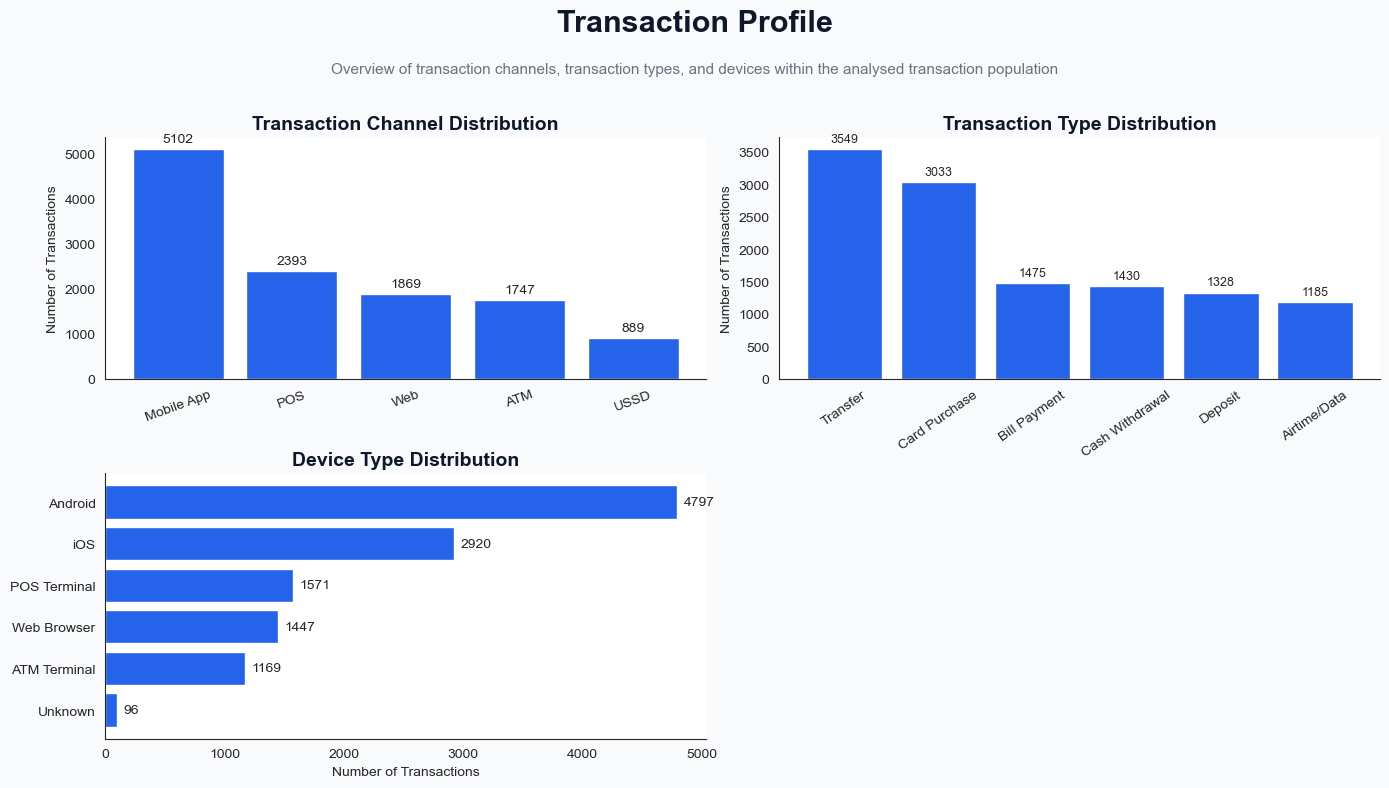

In [84]:


sns.set_style("white")

# Data

channel = df["Channel"].value_counts()

transaction_type = df["Transaction_Type"].value_counts()

device_type = df["Device_Type"].value_counts()

# Colour

primary =  '#2563EB'

# Create figure

fig = plt.figure(figsize=(14, 8))

fig.patch.set_facecolor('#F8FAFC')

gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1, 1.1]
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])

# Transaction Channel

bars1 = ax1.bar(
    channel.index,
    channel.values,
    color=primary
)

ax1.set_title(
    'Transaction Channel Distribution',
    fontsize=14,
    fontweight='bold',
    color='#0F172A'
)

ax1.set_ylabel('Number of Transactions')

ax1.bar_label(
    bars1,
    padding=3,
    fontsize=10
)

ax1.spines[['top', 'right']].set_visible(False)

ax1.tick_params(
    axis='x',
    rotation=20
)

# Transaction Type

bars2 = ax2.bar(
    transaction_type.index,
    transaction_type.values,
    color=primary
)

ax2.set_title(
    'Transaction Type Distribution',
    fontsize=14,
    fontweight='bold',
    color='#0F172A'
)

ax2.set_ylabel('Number of Transactions')

ax2.tick_params(
    axis='x',
    rotation=35
)

ax2.bar_label(
    bars2,
    padding=3,
    fontsize=9
)

ax2.spines[['top', 'right']].set_visible(False)

# Device Type

device_sorted = device_type.sort_values(
    ascending=False
)

bars3 = ax3.barh(
    device_sorted.index,
    device_sorted.values,
    color=primary
)

ax3.set_title(
    'Device Type Distribution',
    fontsize=14,
    fontweight='bold',
    color='#0F172A'
)

ax3.set_xlabel('Number of Transactions')

ax3.bar_label(
    bars3,
    padding=5,
    fontsize=10
)

ax3.spines[['top', 'right']].set_visible(False)

ax3.invert_yaxis()

# Main title

plt.suptitle(
    'Transaction Profile',
    fontsize=22,
    fontweight='bold',
    color='#0F172A',
    y=0.98
)

# Subtitle

fig.text(
    0.5,
    0.90,
    'Overview of transaction channels, transaction types, and devices within the analysed transaction population',
    ha='center',
    fontsize=11,
    color='#6B7280'
)

# Layout

plt.tight_layout(
    rect=[0, 0, 1, 0.92]
)

plt.show()

### What the visual shows

The visual shows the distribution of the 12,000 transactions across transaction channels, transaction types, and device types. The Mobile App was the most frequently used channel with 5,102 transactions, followed by POS (2,393), Web (1,869), ATM (1,747), and USSD (889). Transfer was the most common transaction type with 3,549 transactions, followed by Card Purchase (3,033). Android was the most frequently recorded device type with 4,797 transactions, followed by iOS (2,920).

### Why the visual is important

Understanding where and how transactions occur provides context for analysing transaction outcomes and failure patterns. High-volume channels, transaction types, and devices represent a larger proportion of overall transaction activity and are therefore important areas to consider when assessing transaction reliability.

### What business insight can be derived from the finding?

The transaction population was strongly concentrated in mobile and digital activity, with the Mobile App accounting for approximately 42.5% of all transactions and Android and iOS together accounting for approximately 64.3% of transactions. Transfers and Card Purchases were also the two most common transaction types. This indicates that mobile and commonly used transaction types are important areas to monitor when investigating transaction reliability and customer experience.

### Profile Summary

The analysis covers 12,000 transactions across multiple customer segments, account types, channels, and device types.
Everyday and Premium customers represented substantial shares of the transaction population.
Digital channels and mobile devices accounted for a significant proportion of transaction activity.
The dataset contains a broad range of transaction types, providing a diverse basis for analysing transaction failure patterns.

## Findings: Failure Summary

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")

# Data

risk_failure = (
    df.groupby("Risk_Review_Flag")["Transaction_Status"]
    .apply(lambda x: (x == "Failed").mean() * 100)
    .sort_values(ascending=False)
)

device_failure = (
    df.groupby("Device_Type")["Transaction_Status"]
    .apply(lambda x: (x == "Failed").mean() * 100)
    .sort_values(ascending=True)
)

time_order = [
    "Morning",
    "Afternoon",
    "Evening",
    "Night"
]

time_failure = (
    df.groupby("Time_of_Day")["Transaction_Status"]
    .apply(lambda x: (x == "Failed").mean() * 100)
    .reindex(time_order)
)

international_failure = (
    df.groupby("International_Transaction")["Transaction_Status"]
    .apply(lambda x: (x == "Failed").mean() * 100)
)

# Colour

finding_color = '#1D4ED8'

# Create figure

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 11)
)

fig.patch.set_facecolor('#F8FAFC')

# Risk Review

bars1 = axes[0, 0].bar(
    risk_failure.index.astype(str),
    risk_failure.values,
    color=finding_color
)

axes[0, 0].set_title(
    'Failure Rate by Risk Review',
    fontsize=14,
    fontweight='bold',
    color='#0F172A'
)

axes[0, 0].set_xlabel('Risk Review')
axes[0, 0].set_ylabel('Failure Rate (%)')

axes[0, 0].bar_label(
    bars1,
    fmt='%.2f%%',
    padding=3,
    fontsize=10
)

axes[0, 0].spines[['top', 'right']].set_visible(False)


# Device Type

bars2 = axes[0, 1].barh(
    device_failure.index,
    device_failure.values,
    color=finding_color
)

axes[0, 1].set_title(
    'Failure Rate by Device Type',
    fontsize=14,
    fontweight='bold',
    color='#0F172A'
)

axes[0, 1].set_xlabel('Failure Rate (%)')
axes[0, 1].set_ylabel('Device Type')

axes[0, 1].bar_label(
    bars2,
    fmt='%.2f%%',
    padding=4,
    fontsize=9
)

axes[0, 1].spines[['top', 'right']].set_visible(False)


# Time of Day

axes[1, 0].plot(
    time_failure.index,
    time_failure.values,
    marker='o',
    linewidth=2.5,
    color=finding_color
)

axes[1, 0].set_title(
    'Failure Rate by Time of Day',
    fontsize=14,
    fontweight='bold',
    color='#0F172A'
)

axes[1, 0].set_xlabel('Time of Day')
axes[1, 0].set_ylabel('Failure Rate (%)')

axes[1, 0].spines[['top', 'right']].set_visible(False)


# International Transaction

bars4 = axes[1, 1].bar(
    international_failure.index.astype(str),
    international_failure.values,
    color=finding_color
)

axes[1, 1].set_title(
    'Failure Rate by International Transaction',
    fontsize=14,
    fontweight='bold',
    color='#0F172A'
)

axes[1, 1].set_xlabel('International Transaction')
axes[1, 1].set_ylabel('Failure Rate (%)')

axes[1, 1].bar_label(
    bars4,
    fmt='%.2f%%',
    padding=3,
    fontsize=10
)

axes[1, 1].spines[['top', 'right']].set_visible(False)


# Main title

plt.suptitle(
    'Transaction Failure Findings',
    fontsize=22,
    fontweight='bold',
    color='#0F172A',
    y=0.98
)

# Subtitle

fig.text(
    0.5,
    0.94,
    'Failure-rate patterns across risk review, device type, time of day, and international transactions',
    ha='center',
    fontsize=11,
    color='#6B7280'
)

# Layout

plt.tight_layout(
    rect=[0, 0, 1, 0.92]
)

plt.show()

### What the visual shows

The visual compares transaction failure rates across four areas: risk-review status, device type, time of day, and international transaction status. Risk-reviewed transactions recorded a failure rate of 7.23%, compared with 4.77% for non-risk-reviewed transactions. Among device categories, iOS recorded the highest failure rate at 5.75%. Failure rates were highest during the Afternoon (5.93%) and Evening (5.90%), while domestic transactions recorded a failure rate of 5.36%, compared with 2.50% for international transactions.

### Why the visual is important

The visual is important because it identifies differences in transaction failure rates across several operational and transaction characteristics. Comparing these groups helps identify areas where transaction failures are more concentrated and provides direction for further investigation.

### What business insight can be derived from the finding?

The analysis identified several areas with relatively higher observed failure rates. Risk-reviewed transactions, iOS transactions, afternoon and evening activity, and domestic transactions recorded higher failure rates within their respective comparisons. These patterns can help FinTrust prioritise further investigation into transaction controls, device-specific processes, transaction timing, and domestic transaction activity. The findings indicate associations within the dataset and do not by themselves establish the underlying causes of the failures.

### Finding Summary

Risk-reviewed transactions recorded a higher failure rate than transactions without a risk review.
iOS recorded the highest failure rate among the main device categories.
Failure rates were higher during the afternoon and evening compared with the morning and night.
International transactions recorded a lower failure rate, although they represented a much smaller transaction population.

## Deeper Findings: Deeper Analysis Summary

In [ ]:
sns.set_style("white")

# Data

deeper_df = df[df["Device_Type"] != "Unknown"]

deeper_failure = (
    deeper_df.pivot_table(
        index="Device_Type",
        columns="Risk_Review_Flag",
        values="Transaction_Status",
        aggfunc=lambda x: (x == "Failed").mean() * 100
    )
)

deeper_failure = deeper_failure.reindex(
    columns=["No", "Yes"]
)

deeper_failure = deeper_failure.sort_values(
    "Yes",
    ascending=True
)

# Create figure

fig, ax = plt.subplots(
    figsize=(10, 7)
)

fig.patch.set_facecolor('#F8FAFC')

# Heatmap

sns.heatmap(
    deeper_failure,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'Failure Rate (%)'},
    ax=ax
)

# Main title

plt.suptitle(
    'Deeper Finding: Failure Rate by Device Type and Risk Review',
    fontsize=18,
    fontweight='bold',
    color='#0F172A',
    y=0.98
)

# Subtitle

fig.text(
    0.5,
    0.92,
    'Comparison of transaction failure rates across device types and risk-review status',
    ha='center',
    fontsize=11,
    color='#6B7280'
)

# Axis labels

ax.set_xlabel(
    'Risk Review',
    fontsize=11
)

ax.set_ylabel(
    'Device Type',
    fontsize=11
)

# Layout

plt.tight_layout(
    rect=[0, 0, 1, 0.88]
)

plt.show()

### What does the visual show?

The heatmap compares transaction failure rates across device types and risk-review status. Among risk-reviewed transactions, iOS recorded the highest failure rate at 9.26%, followed by ATM Terminal at 7.51%, Android at 7.11%, POS Terminal at 6.78%, and Web Browser at 3.78%. For non-risk-reviewed transactions, the corresponding rates were 4.96% for iOS, 4.15% for ATM Terminal, 4.95% for Android, 4.47% for POS Terminal, and 4.58% for Web Browser.

### Why is it important?

The visual examines device type and risk-review status together rather than analysing them separately. This helps identify whether failure-rate differences across devices are consistent between risk-reviewed and non-risk-reviewed transactions and highlights specific combinations that may warrant further investigation.

### What business insight can be derived?

Risk-reviewed transactions recorded higher failure rates across most identified device types. The largest difference was observed for iOS, where the failure rate increased from 4.96% for non-risk-reviewed transactions to 9.26% for risk-reviewed transactions. ATM Terminal, Android, and POS Terminal also recorded higher failure rates when risk-reviewed. Web Browser was the exception, with a lower failure rate for risk-reviewed transactions (3.78%) than for non-risk-reviewed transactions (4.58%).

This suggests that the relationship between risk review and transaction failures may vary by device type. Further investigation could examine whether transaction type, authentication requirements, or other characteristics of risk-reviewed transactions explain these differences. These results indicate an association and do not establish that risk review or device type causes transaction failures.

### Deeper Finding Summary

The combined analysis shows that failure rates vary across device type and risk-review status.
Risk-reviewed transactions generally recorded higher failure rates across device categories, providing an area for further investigation.
The results should be interpreted alongside transaction volumes, particularly for smaller device groups.

## Recommendation

### Recommendation 1: Review Risk-Review Processes

Observed Pattern
Risk-reviewed transactions recorded a 7.23% failure rate, compared with 4.77% for non-risk-reviewed transactions.

Recommendation
Review risk rules, authentication requirements, and transaction-processing controls to identify factors associated with the higher failure rate.

Expected Impact
Improved transaction completion rates and more effective risk controls.

### Recommendation 2: Investigate iOS Transactions

Observed Pattern
iOS transactions recorded the highest failure rate among the main device categories at 5.75%. Among risk-reviewed iOS transactions, the failure rate increased to 9.26%.

Recommendation
Investigate iOS transaction failures, focusing on authentication outcomes, risk-rule triggers, and transaction-processing issues.

Expected Impact
Improved transaction reliability and identification of potential device-specific technical or operational issues.

### Recommendation 3: Monitor Peak Transaction Periods

Observed Pattern
Failure rates were higher during the afternoon (5.93%) and evening (5.90%) compared with other periods of the day.

Recommendation
Monitor transaction performance during afternoon and evening periods, focusing on transaction volumes, system performance, processing capacity, and error trends.

Expected Impact
Improved transaction reliability during higher-activity periods and reduced transaction failures.

In [ ]:
# Save cleaned datasets

customers.to_csv("FinTrust_Customers_Cleaned_Data.csv", index=False)

transactions.to_csv("FinTrust_Transactions_Cleaned_Data.csv", index=False)

In [ ]:
account_type = (
    df["Account_Type"]
    .value_counts()
    .reindex(["Savings", "Current", "Premium"])
)

In [ ]:
account_type